# Regularized Regression — Notebook 01 · Least Squares and Ridge

**Regularized Regression — From Likelihood to Lasso**

Covers **Task 1** (maximum likelihood by hand, and two ways for it to fail) and **Task 2** (Ridge as MAP with a Gaussian prior).

---

### How to run this

Put `uber_surge_mumbai.csv` (and, for notebook 02, `new_city_features.csv` and
`new_city_truth.csv`) in a `data/` folder beside this notebook, or upload them to your
Colab session. If the files are missing, the next cell regenerates them from the same
seed, so nothing here breaks either way.

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=110)
pd.set_option('display.width', 120, 'display.max_columns', 30)

# --- a consistent look for every figure in this course -----------------------
plt.rcParams.update({
    'figure.figsize': (9, 4.6), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': .28, 'grid.linewidth': .7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cbc3', 'axes.labelcolor': '#4c514f',
    'axes.titlesize': 12, 'axes.titleweight': '600', 'axes.labelsize': 10,
    'xtick.color': '#767d7a', 'ytick.color': '#767d7a',
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'font.size': 10, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
C = {'ols': '#767d7a', 'ridge': '#2b5fa8', 'lasso': '#b4700c',
     'enet': '#5b4bb5', 'accent': '#1f6f5c', 'rose': '#b03a52'}

# Look in the usual places: beside the notebook, in ./data, or one level up
# (which is where the repo keeps them if you opened this from notebooks/).
SEARCH = ['data', '.', '../data', '..', '../../data']

def load(name):
    """Load a course CSV, regenerating it from the seed if it cannot be found."""
    for d in SEARCH:
        path = os.path.join(d, name)
        if os.path.exists(path):
            return pd.read_csv(path)
    for cand in ('scripts/make_data.py', 'make_data.py', '../scripts/make_data.py'):
        if os.path.exists(cand):
            subprocess.run([sys.executable, cand], check=True)
            return load(name)
    raise FileNotFoundError(
        f"{name} not found. Download it from the course site's Data page and put it "
        f"in a data/ folder beside this notebook.")

df = load('uber_surge_mumbai.csv')
print(f'{len(df)} trips, {df.shape[1]} columns')
df.head(3)

200 trips, 19 columns


,trip_id,zone,hour,is_peak,is_weekend,is_rain,is_event_nearby,is_airport_pickup,traffic_speed_kmph,drivers_available_500m,open_requests_500m,historical_demand,distance_km,time_min,base_fare_inr,surge_additive_inr,final_fare_inr,demand_supply_ratio,is_bad_weather
0,1,Powai,2,0,1,0,0,0,43.4,31,13,14.0,18.21,33.6,325.7,27.8,353.5,0.419,0
1,2,Lower Parel,18,1,0,1,1,0,22.8,6,46,46.2,15.06,42.7,306.1,150.0,456.1,7.667,1
2,3,Andheri East,15,0,0,0,1,0,47.3,17,25,26.4,3.24,7.8,94.5,65.7,160.2,1.471,0


In [2]:
# ---------------------------------------------------------------------------
# Conventions used throughout this course. Read these once; they save hours.
#
#   Objective (identical to sklearn's ElasticNet, including the 1/2n):
#       (1/2n)||y - Xw||^2  +  alpha*rho*||w||_1  +  (alpha*(1-rho)/2)*||w||^2
#
#   So the Ridge CLOSED FORM needs  n*alpha  where sklearn's Ridge takes alpha:
#       w = (X^T X + n*alpha*I)^-1 X^T y
#
#   Standardize on the TRAINING rows only, then apply that scaler to the test
#   rows. Split by time, never shuffled: trips 1-150 train, 151-200 test.
# ---------------------------------------------------------------------------
BASE8 = ['is_peak', 'is_rain', 'traffic_speed_kmph', 'drivers_available_500m',
         'is_event_nearby', 'is_airport_pickup', 'is_weekend', 'open_requests_500m']
SHORT = {'is_peak': 'is_peak', 'is_rain': 'is_rain',
         'traffic_speed_kmph': 'traffic_speed', 'drivers_available_500m': 'drivers_avail',
         'is_event_nearby': 'is_event', 'is_airport_pickup': 'is_airport',
         'is_weekend': 'is_weekend', 'open_requests_500m': 'open_requests',
         'is_bad_weather': 'is_bad_weather'}
N_TRAIN, SIGMA, TAU = 150, 10.0, 1.0

def split(frame, features):
    X = frame[features].to_numpy(float)
    y = frame['surge_additive_inr'].to_numpy(float)
    return X[:N_TRAIN], X[N_TRAIN:], y[:N_TRAIN], y[N_TRAIN:]

def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd = np.where(sd == 0, 1e-8, sd)
    return (Xtr - mu) / sd, (Xte - mu) / sd, mu, sd

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def r2(y, yhat):
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))

print('conventions loaded')

conventions loaded


## Task 1a — An ill-conditioned pair

`is_rain` and `traffic_speed_kmph` on the **first six trips**. The two columns are
strongly correlated, and six rows leave barely enough independent variation to tell them
apart.

In [3]:
A_FEATS = ['is_rain', 'traffic_speed_kmph']
n6 = 6

X = df[A_FEATS].to_numpy(float)[:n6]
y = df['surge_additive_inr'].to_numpy(float)[:n6]

# Standardize using ONLY these six rows: the estimator sees nothing else.
mu, sd = X.mean(0), X.std(0)
Z = (X - mu) / sd
yc = y - y.mean()

print('standardized design matrix Z:')
print(Z)
print('\ncentred target:', np.round(yc, 2))
print('\nsample correlation r =', round(float(np.corrcoef(X[:, 0], X[:, 1])[0, 1]), 4))

standardized design matrix Z:
[[-1.      1.064 ]
 [ 1.     -0.8201]
 [-1.      1.4208]
 [ 1.     -1.2134]
 [-1.      0.3232]
 [ 1.     -0.7744]]

centred target: [-79.33  42.87 -41.43  42.87  -7.83  42.87]

sample correlation r = -0.936


### Step 1 — build $X^\top X$ and $X^\top y$ by hand

Each entry of $X^\top X$ is a dot product of two columns. Since the columns are
standardized, the diagonal entries are exactly $n$ and the off-diagonal is $n\,r$, which
is why the correlation coefficient is the number that matters here.

In [4]:
XtX = Z.T @ Z
Xty = Z.T @ yc

print('XtX =\n', XtX)
print('\ncheck by hand:')
print('  (1,1) = sum(z1^2)   =', round(float((Z[:, 0] ** 2).sum()), 4))
print('  (1,2) = sum(z1*z2)  =', round(float((Z[:, 0] * Z[:, 1]).sum()), 4))
print('  (2,2) = sum(z2^2)   =', round(float((Z[:, 1] ** 2).sum()), 4))
print('\nXty =', np.round(Xty, 4))

XtX =
 [[ 6.    -5.616]
 [-5.616  6.   ]]

check by hand:
  (1,1) = sum(z1^2)   = 6.0
  (1,2) = sum(z1*z2)  = -5.616
  (2,2) = sum(z2^2)   = 6.0

Xty = [ 257.2    -266.1824]


### Step 2 — determinant and the explicit inverse

For a $2\times2$ matrix,
$\begin{pmatrix}a&b\\b&d\end{pmatrix}^{-1} = \frac{1}{ad-b^2}\begin{pmatrix}d&-b\\-b&a\end{pmatrix}$.

The inverse divides by the determinant, so everything the estimator produces —
coefficients and their standard errors — is scaled by $1/\det$.

In [5]:
a, b, d = XtX[0, 0], XtX[0, 1], XtX[1, 1]
det = a * d - b * b
XtX_inv = np.array([[d, -b], [-b, a]]) / det

print(f'det(XtX)        = {det:.4f}')
print(f'1/det           = {1/det:.4f}   <- every coefficient is scaled by this')
print(f'condition number= {np.linalg.cond(XtX):.1f}')
print('\ninverse =\n', XtX_inv)
print('\nagrees with np.linalg.inv:', np.allclose(XtX_inv, np.linalg.inv(XtX)))

w6 = XtX_inv @ Xty
print(f'\nw_MLE = ({w6[0]:.3f}, {w6[1]:.3f})   [Rs per standard deviation]')

det(XtX)        = 4.4607
1/det           = 0.2242   <- every coefficient is scaled by this
condition number= 30.2

inverse =
 [[1.3451 1.259 ]
 [1.259  1.3451]]

agrees with np.linalg.inv: True

w_MLE = (10.833, -34.224)   [Rs per standard deviation]


In [6]:
# Prediction for trip 2 (19:00, peak and rain, 6 drivers)
pred2 = float(Z[1] @ w6 + y.mean())
print(f'predicted surge for trip 2: Rs {pred2:.2f}')
print(f'actually charged:           Rs {y[1]:.0f}')
print('\nClose — but the model saw six points, two of them at the price cap.')

predicted surge for trip 2: Rs 146.03
actually charged:           Rs 150

Close — but the model saw six points, two of them at the price cap.


### Step 3 — add trips one at a time

Refit on the first $n = 6, 7, \dots, 15$ trips and watch the coefficients. In a
well-posed problem, adding one observation out of six would nudge the answer.

In [7]:
rows, prev = [], None
for n in range(6, 16):
    Xn = df[A_FEATS].to_numpy(float)[:n]
    yn = df['surge_additive_inr'].to_numpy(float)[:n]
    Zn = (Xn - Xn.mean(0)) / Xn.std(0)
    An = Zn.T @ Zn
    wn = np.linalg.solve(An, Zn.T @ (yn - yn.mean()))
    jump = None if prev is None else float(np.max(np.abs(wn - prev)))
    rows.append({'n': n,
                 'r': round(float(np.corrcoef(Xn[:, 0], Xn[:, 1])[0, 1]), 3),
                 'det': round(float(np.linalg.det(An)), 2),
                 'w_is_rain': round(float(wn[0]), 2),
                 'w_traffic': round(float(wn[1]), 2),
                 'max_move': None if jump is None else round(jump, 2)})
    prev = wn

inst = pd.DataFrame(rows)
print(inst.to_string(index=False))
print(f"\nLargest single-observation move: Rs {inst.max_move.max():.2f} per s.d.")

 n      r   det  w_is_rain  w_traffic  max_move
 6 -0.936  4.46      10.83     -34.22       NaN
 7 -0.928  6.84      21.69     -23.85     10.85
 8 -0.922  9.62      28.83     -16.77      7.15
 9 -0.918 12.71      23.54     -23.85      7.08
10 -0.919 15.46      20.69     -27.38      3.53
11 -0.920 18.62      25.63     -18.60      8.78
12 -0.920 22.18      23.57     -20.50      2.06
13 -0.918 26.62      20.27     -24.20      3.70
14 -0.915 32.03      25.81     -21.58      5.54
15 -0.914 37.01      27.59     -19.33      2.26

Largest single-observation move: Rs 10.85 per s.d.


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


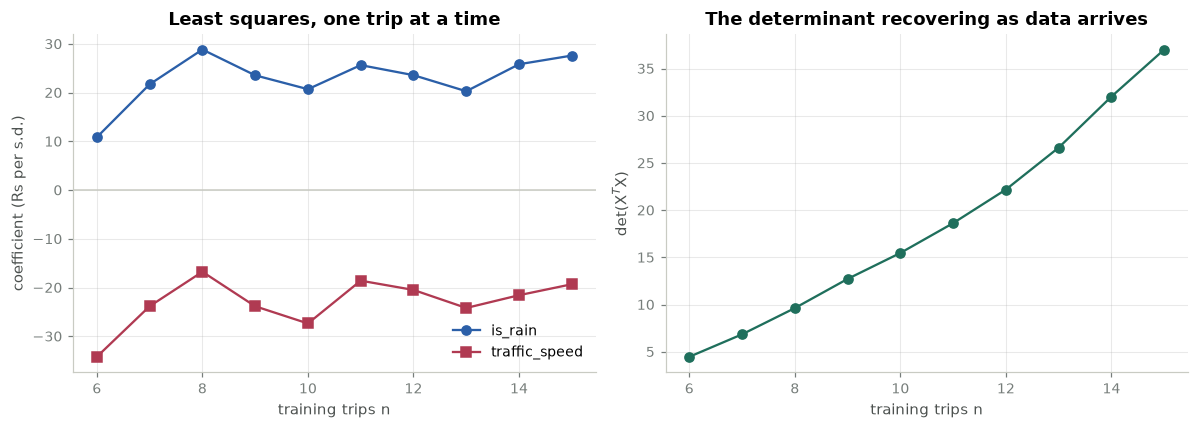

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(inst.n, inst.w_is_rain, 'o-', color=C['ridge'], label='is_rain')
ax[0].plot(inst.n, inst.w_traffic, 's-', color=C['rose'], label='traffic_speed')
ax[0].axhline(0, color='#c9cbc3', lw=1)
ax[0].set(xlabel='training trips n', ylabel='coefficient (Rs per s.d.)',
          title='Least squares, one trip at a time')
ax[0].legend()
ax[1].plot(inst.n, inst.det, 'o-', color=C['accent'])
ax[1].set(xlabel='training trips n', ylabel='det(X$^T$X)',
          title='The determinant recovering as data arrives')
plt.tight_layout(); plt.show()

> **Write-up prompt (Task 1a).** Reporting that the coefficients move is not enough.
> Explain why, in terms of the determinant and the $-r$ off-diagonal of the inverse. One
> useful extra check: is the **sum** of the two coefficients more stable than either
> alone? If so, what does that say about which quantity the data identifies?

## Task 1b — A pair where OLS does not exist

Now `is_rain` and `is_bad_weather` on the **first ten trips**.

In [9]:
df['is_bad_weather'] = ((df.is_rain == 1) & (df.traffic_speed_kmph < 25)).astype(int)

sub = df[['is_rain', 'traffic_speed_kmph', 'is_bad_weather']].head(10)
print(sub.to_string())
print('\ncolumns identical on these rows:',
      bool((sub.is_rain == sub.is_bad_weather).all()))

   is_rain  traffic_speed_kmph  is_bad_weather
0        0                43.4               0
1        1                22.8               1
2        0                47.3               0
3        1                18.5               1
4        0                35.3               0
5        1                23.3               1
6        0                37.5               0
7        0                37.2               0
8        0                45.9               0
9        0                45.0               0

columns identical on these rows: True


In [10]:
Xb = df[['is_rain', 'is_bad_weather']].to_numpy(float)[:10]
yb = df['surge_additive_inr'].to_numpy(float)[:10]
Zb = (Xb - Xb.mean(0)) / Xb.std(0)
Ab = Zb.T @ Zb

print('XtX =\n', Ab)
print(f'\ndet = {np.linalg.det(Ab):.10f}')
try:
    np.linalg.inv(Ab)
except np.linalg.LinAlgError as e:
    print('np.linalg.inv raised:', type(e).__name__, '-', e)

# When does it become solvable?
for n in range(4, 30):
    Xn = df[['is_rain', 'is_bad_weather']].to_numpy(float)[:n]
    if Xn.std(0).min() == 0:
        continue
    Zn = (Xn - Xn.mean(0)) / Xn.std(0)
    if abs(np.linalg.det(Zn.T @ Zn)) > 1e-8:
        print(f'\nfirst solvable at n = {n}')
        break

XtX =
 [[10. 10.]
 [10. 10.]]

det = 0.0000000000
np.linalg.inv raised: LinAlgError - Singular matrix

first solvable at n = 14


> **Write-up prompt (Task 1b, step 3).** "The MLE does not exist" is a claim about the
> likelihood surface, not about NumPy. Adding $c$ to one coefficient and subtracting $c$
> from the other changes no prediction, so the likelihood has a flat direction and no
> unique maximum. Say that in one sentence, in your own words.

## Task 1c — The real thing: eight features, 150 trips

In [11]:
Xtr, Xte, ytr, yte = split(df, BASE8)
Ztr, Zte, mu8, sd8 = standardize(Xtr, Xte)
ybar = ytr.mean()

w_ols = np.linalg.solve(Ztr.T @ Ztr, Ztr.T @ (ytr - ybar))

print(pd.Series({SHORT[f]: round(float(v), 2) for f, v in zip(BASE8, w_ols)},
                name='coef (Rs per s.d.)').to_string())
print(f'\ncondition number of XtX : {np.linalg.cond(Ztr.T @ Ztr):.1f}')
print(f'train RMSE              : Rs {rmse(ytr, Ztr @ w_ols + ybar):.2f}')
print(f'test  RMSE              : Rs {rmse(yte, Zte @ w_ols + ybar):.2f}')
print(f'test  R2                : {r2(yte, Zte @ w_ols + ybar):.3f}')

is_peak          18.84
is_rain          12.65
traffic_speed   -16.52
drivers_avail    -0.98
is_event          7.42
is_airport        8.29
is_weekend       -0.17
open_requests     1.84

condition number of XtX : 37.6
train RMSE              : Rs 9.15
test  RMSE              : Rs 13.24
test  R2                : 0.928


> **Note the condition number.** An order of magnitude better than the six-row problem.
> With 150 trips and 8 features this dataset is not ill-conditioned, which is worth
> remembering when cross-validation picks a tiny penalty in Task 2.

---

## Task 2 — Ridge regression as MAP

Gaussian prior $w \sim \mathcal{N}(0, \tau^2)$ gives
$\hat w = (X^\top X + \lambda I)^{-1}X^\top y$ with $\lambda = \sigma^2/\tau^2$.

Use `np.linalg.solve`, not `np.linalg.inv`: the explicit inverse is slower and
numerically worse. Task 1 formed one only because we wanted to look at it.

In [12]:
def ridge_fit(Z, y, alpha_sklearn):
    """Closed-form ridge on the sklearn alpha scale (no 1/n in the loss)."""
    p = Z.shape[1]
    return np.linalg.solve(Z.T @ Z + alpha_sklearn * np.eye(p), Z.T @ y)

yc_tr = ytr - ybar
grid = [0.1, 1, 10, 100, 1000]
rows = []
for a in grid:
    w = ridge_fit(Ztr, yc_tr, a)
    rows.append({'alpha': a,
                 **{SHORT[f]: round(float(v), 2) for f, v in zip(BASE8, w)},
                 'gap_peak_rain': round(float(abs(w[0] - w[1])), 2),
                 'train_rmse': round(rmse(ytr, Ztr @ w + ybar), 2),
                 'test_rmse': round(rmse(yte, Zte @ w + ybar), 2)})
ridge_table = pd.DataFrame(rows)
print(ridge_table.to_string(index=False))

 alpha  is_peak  is_rain  traffic_speed  drivers_avail  is_event  is_airport  is_weekend  open_requests  gap_peak_rain  train_rmse  test_rmse
   0.1    18.79    12.61         -16.53          -1.01      7.40        8.28       -0.16           1.87           6.18        9.15      13.23
   1.0    18.34    12.31         -16.62          -1.29      7.27        8.24       -0.09           2.13           6.03        9.15      13.22
  10.0    15.61    10.53         -16.51          -3.17      6.35        7.81        0.41           3.84           5.08        9.40      13.29
 100.0    10.25     7.23         -12.02          -6.12      3.63        4.94        0.73           6.50           3.03       13.54      16.71
1000.0     3.63     2.68          -4.11          -3.01      1.02        0.98       -0.04           3.07           0.96       31.55      35.96


In [13]:
# Verify against scikit-learn (allowed here: we are CHECKING, not computing)
from sklearn.linear_model import Ridge
for a in grid:
    mine = ridge_fit(Ztr, yc_tr, a)
    theirs = Ridge(alpha=a, fit_intercept=False).fit(Ztr, yc_tr).coef_
    print(f'alpha={a:>6}:  max |difference| = {np.max(np.abs(mine - theirs)):.2e}')

alpha=   0.1:  max |difference| = 7.11e-15
alpha=     1:  max |difference| = 5.55e-15
alpha=    10:  max |difference| = 7.99e-15
alpha=   100:  max |difference| = 2.66e-15
alpha=  1000:  max |difference| = 8.88e-16


### The coefficient path (Deliverable 1, panel 1)

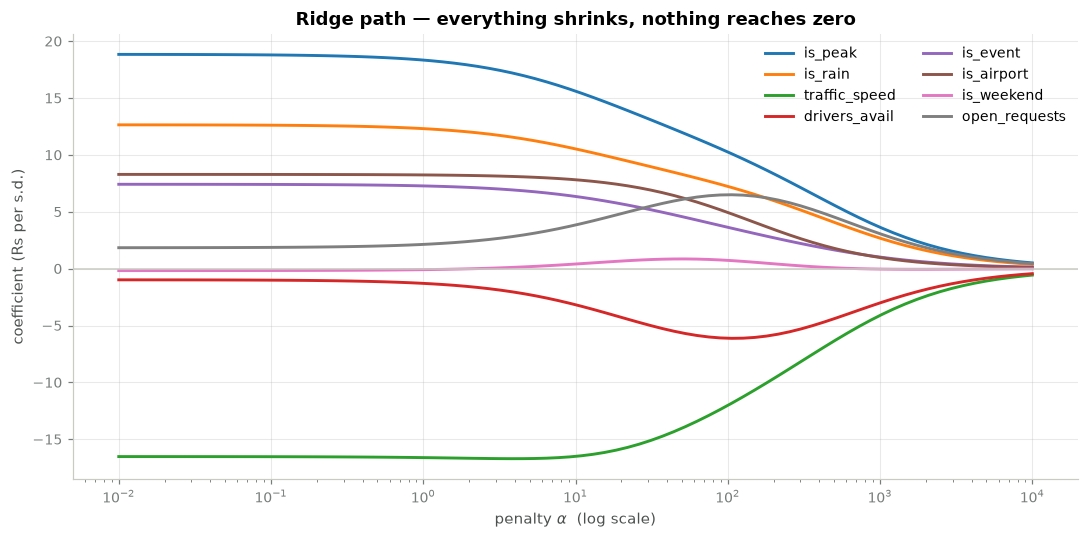

gap between is_peak and is_rain:
  alpha=     0.01   |gap| =  6.19
  alpha=     0.16   |gap| =  6.17
  alpha=     2.69   |gap| =  5.78
  alpha=    44.21   |gap| =  3.80
  alpha=   725.70   |gap| =  1.19

The gap falls monotonically: the two correlated features converge toward
each other rather than meeting at some particular alpha.


In [14]:
alphas = np.logspace(-2, 4, 80)
paths = np.array([ridge_fit(Ztr, yc_tr, a) for a in alphas])

fig, ax = plt.subplots(figsize=(10, 5))
for j, f in enumerate(BASE8):
    ax.plot(alphas, paths[:, j], lw=1.9, label=SHORT[f])
ax.set_xscale('log')
ax.axhline(0, color='#c9cbc3', lw=1)
ax.set(xlabel=r'penalty $\alpha$  (log scale)', ylabel='coefficient (Rs per s.d.)',
       title='Ridge path — everything shrinks, nothing reaches zero')
ax.legend(ncol=2, loc='upper right')
plt.tight_layout(); plt.show()

gaps = np.abs(paths[:, 0] - paths[:, 1])
print('gap between is_peak and is_rain:')
for a, g in zip(alphas[::16], gaps[::16]):
    print(f'  alpha={a:9.2f}   |gap| = {g:5.2f}')
print('\nThe gap falls monotonically: the two correlated features converge toward')
print('each other rather than meeting at some particular alpha.')

### Choosing $\alpha$ honestly

Cross-validate **on the training split only**. The test set is for reporting, once.

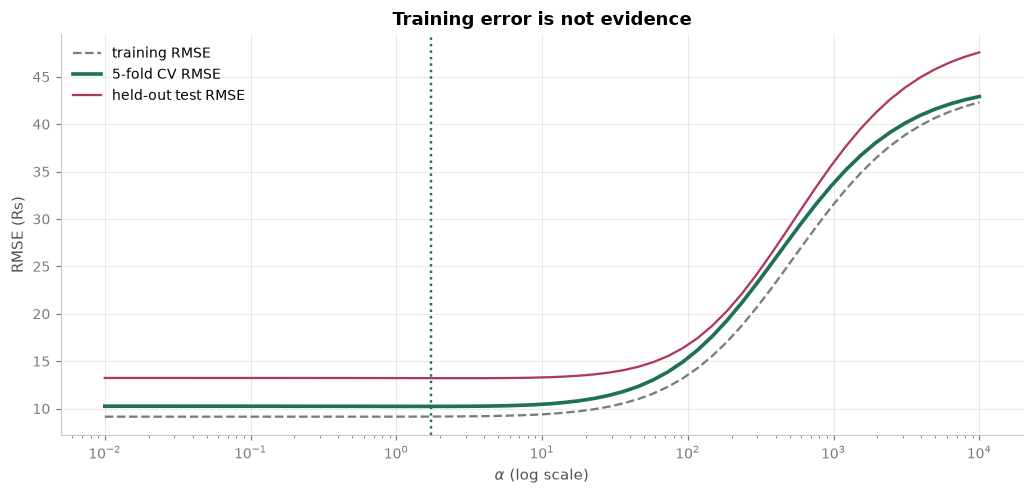

CV-optimal alpha        : 1.727
CV RMSE there           : Rs 10.24
test RMSE there         : Rs 13.21
prior says lambda       : 100
test RMSE at lambda=100 : Rs 16.71


In [15]:
def kfold_cv(Z, y, k, fit):
    n = len(y)
    idx = np.arange(n)
    total = 0.0
    for f in range(k):
        te = np.zeros(n, bool); te[idx[f::k]] = True
        ybar_f = y[~te].mean()
        w = fit(Z[~te], y[~te] - ybar_f)
        total += np.sum((y[te] - (Z[te] @ w + ybar_f)) ** 2)
    return float(np.sqrt(total / n))

cv_grid = np.logspace(-2, 4, 60)
cv_scores = [kfold_cv(Ztr, ytr, 5, lambda Z, t, a=a: ridge_fit(Z, t, a)) for a in cv_grid]
best_i = int(np.argmin(cv_scores))
best_alpha = float(cv_grid[best_i])

train_e = [rmse(ytr, Ztr @ ridge_fit(Ztr, yc_tr, a) + ybar) for a in cv_grid]
test_e = [rmse(yte, Zte @ ridge_fit(Ztr, yc_tr, a) + ybar) for a in cv_grid]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(cv_grid, train_e, '--', color=C['ols'], label='training RMSE')
ax.plot(cv_grid, cv_scores, lw=2.4, color=C['accent'], label='5-fold CV RMSE')
ax.plot(cv_grid, test_e, color=C['rose'], label='held-out test RMSE')
ax.axvline(best_alpha, color=C['accent'], ls=':', lw=1.6)
ax.set_xscale('log')
ax.set(xlabel=r'$\alpha$ (log scale)', ylabel='RMSE (Rs)',
       title='Training error is not evidence')
ax.legend()
plt.tight_layout(); plt.show()

print(f'CV-optimal alpha        : {best_alpha:.3f}')
print(f'CV RMSE there           : Rs {cv_scores[best_i]:.2f}')
print(f'test RMSE there         : Rs {test_e[best_i]:.2f}')
print(f'prior says lambda       : {SIGMA**2/TAU**2:.0f}')
print(f'test RMSE at lambda=100 : Rs {rmse(yte, Zte @ ridge_fit(Ztr, yc_tr, 100) + ybar):.2f}')

> **Write-up prompt (Task 2, step 6).** Cross-validation and the stated prior disagree by
> a wide margin. The prior $\tau = 1$ asserts coefficients of about $\pm1$ rupee per
> standard deviation; the data says about $\pm10$. Which do you trust with 150
> observations, and what does the disagreement say about the prior?

---

### Checklist before you move on

- [ ] `XtX` computed by hand and cross-checked against NumPy
- [ ] Instability table produced, with the largest one-trip move quoted
- [ ] Singular case reproduced, and explained as a property of the likelihood
- [ ] Ridge implemented with `solve`, matching sklearn to ~1e-14
- [ ] Coefficient path plotted with a log x-axis (**Deliverable 1**)
- [ ] CV run on the training split only, and the CV-vs-prior disagreement discussed

Next: **Notebook 02 — Lasso by coordinate descent**.